<a href="https://colab.research.google.com/github/DhimanTarafdar/gallbladder_cancer_research/blob/main/Gallbladder_Cancer_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df_expression = pd.read_csv('GSE139682_all.rpkm.txt', sep='\t')
df_expression


,GeneID,Normal 6,Tumor 6,Normal 10,Tumor 10,Normal 9,Tumor 9,Normal 5,Tumor 5,Normal 8,...,Normal 3,Tumor 3,Normal 2,Tumor 2,Normal 1,Tumor 1,Normal 4,Tumor 4,Normal 7,Tumor 7
0,SNORD121B,2.169939,2.933104,1.366928,3.540610,1.065534,1.461295,0.750690,1.610071,1.242228,...,2.088572,2.216190,0.000000,0.906144,0.000000,0.751207,0.825258,3.007184,3.122717,6.607239
1,HTR4,0.802507,0.012952,0.407442,0.125079,1.082211,0.000000,0.232047,0.071099,0.082283,...,0.553372,0.293592,0.174280,0.140050,0.297169,0.033172,0.601299,0.066397,0.482633,3.673617
2,SNORD121A,1.883793,3.564849,4.153357,2.458973,2.775073,8.880178,2.606791,6.289893,2.156835,...,0.000000,4.809862,3.806914,3.933260,0.000000,0.000000,1.432865,1.305316,9.036434,9.386108
3,HTR6,0.025299,0.041036,0.000000,0.016512,0.000000,0.000000,0.035009,0.056314,0.028966,...,0.048700,0.025838,0.000000,0.084516,0.209223,0.052549,0.000000,0.052590,0.024271,0.028012
4,HTR7,0.909112,0.290769,1.064709,0.200568,0.528151,0.034491,0.761904,0.627047,0.791656,...,0.969508,0.418474,0.765933,0.427758,0.453827,0.159578,0.292181,0.195193,0.368531,0.056710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41757,AQP11,0.537445,1.205393,0.802506,1.221206,0.781953,3.753350,2.065879,1.624654,0.455811,...,1.277266,1.667032,0.868889,0.797979,0.611440,1.019869,1.332372,1.572381,1.604146,0.991797
41758,BAX,17.746660,40.575680,16.174305,19.099017,16.223580,14.748137,23.643425,22.623450,18.157324,...,12.417190,11.472687,16.405789,15.767696,13.996271,17.842821,23.191743,11.381262,16.844790,18.865825
41759,OR9N1P,0.000000,0.970144,0.086946,0.090083,0.000000,0.000000,0.190997,0.102412,0.000000,...,0.265696,0.000000,0.000000,0.000000,0.000000,0.095564,0.000000,0.000000,0.132418,0.000000
41760,ABCE1,14.295650,21.580343,17.328430,17.086609,22.981139,19.020181,17.336033,24.929613,21.971797,...,11.631896,21.373497,15.264692,16.590593,10.008075,18.862030,15.622637,14.911694,22.508780,28.285641


In [ ]:
import pandas as pd

# load expression matrix
df_exp = pd.read_csv('GSE139682_all.rpkm.txt', sep='\t')

# check total genes and samples
num_genes, num_cols = df_exp.shape
sample_names = list(df_exp.columns[1:])  # first column is GeneID

print(f"total genes found: {num_genes}")
print(f"total columns (gene_id + samples): {num_cols}")
print(f"total sample count: {len(sample_names)}")
print(f"sample column names: {sample_names}\n")

# check missing values
null_count = df_exp.isnull().sum().sum()
print(f"total missing values in dataset: {null_count}")

# print first 10 gene names
print(f"first 10 gene names: {list(df_exp['GeneID'].head(10))}")

total genes found: 41762
total columns (gene_id + samples): 21
total sample count: 20
sample column names: ['Normal 6', 'Tumor 6', 'Normal 10', 'Tumor 10', 'Normal 9', 'Tumor 9', 'Normal 5', 'Tumor 5', 'Normal 8', 'Tumor 8', 'Normal 3', 'Tumor 3', 'Normal 2', 'Tumor 2', 'Normal 1', 'Tumor 1', 'Normal 4', 'Tumor 4', 'Normal 7', 'Tumor 7']

total missing values in dataset: 0
first 10 gene names: ['SNORD121B', 'HTR4', 'SNORD121A', 'HTR6', 'HTR7', 'LOC100132330', 'BBX', 'RP11-48F14.1', 'LOC100421505', 'WDR83OS']


In [ ]:
# read series matrix file line by line to extract metadata
with open('GSE139682_series_matrix.txt', 'r') as f:
    matrix_lines = f.readlines()

# extract key metadata lines
title_line = [line for line in matrix_lines if line.startswith('!Sample_title')]
source_line = [line for line in matrix_lines if line.startswith('!Sample_source_name_ch1')]
characteristics_lines = [line for line in matrix_lines if line.startswith('!Sample_characteristics_ch1')]

print("--- metadata extraction ---")
if title_line:
    print(f"sample titles:\n{title_line[0].strip()}\n")
if source_line:
    print(f"sample source (tissue/blood type):\n{source_line[0].strip()}\n")

print("sample characteristics (phenotype info):")
for char in characteristics_lines:
    print(char.strip())

--- metadata extraction ---
sample titles:
!Sample_title	"Tumor 1"	"Normal 1"	"Tumor 2"	"Normal 2"	"Tumor 3"	"Normal 3"	"Tumor 4"	"Normal 4"	"Tumor 5"	"Normal 5"	"Tumor 6"	"Normal 6"	"Tumor 7"	"Normal 7"	"Tumor 8"	"Normal 8"	"Tumor 9"	"Normal 9"	"Tumor 10"	"Normal 10"

sample source (tissue/blood type):
!Sample_source_name_ch1	"gallbladder tissue"	"gallbladder tissue"	"gallbladder tissue"	"gallbladder tissue"	"gallbladder tissue"	"gallbladder tissue"	"gallbladder tissue"	"gallbladder tissue"	"gallbladder tissue"	"gallbladder tissue"	"gallbladder tissue"	"gallbladder tissue"	"gallbladder tissue"	"gallbladder tissue"	"gallbladder tissue"	"gallbladder tissue"	"gallbladder tissue"	"gallbladder tissue"	"gallbladder tissue"	"gallbladder tissue"

sample characteristics (phenotype info):
!Sample_characteristics_ch1	"diagnosis: gallbladder cancer"	"diagnosis: gallbladder cancer"	"diagnosis: gallbladder cancer"	"diagnosis: gallbladder cancer"	"diagnosis: gallbladder cancer"	"diagnosis: gallbladd

In [ ]:
# set GeneID as index to compute numeric statistics
numeric_exp = df_exp.set_index('GeneID')

# summary statistics for expression levels
exp_stats = numeric_exp.describe()

print("--- expression statistics summary ---")
print(f"min expression value: {numeric_exp.values.min()}")
print(f"max expression value: {numeric_exp.values.max()}")
print(f"mean expression value: {numeric_exp.values.mean():.4f}")

# print summary table for first 5 samples
print("\nsummary statistics for first 5 samples:")
print(exp_stats.iloc[:, :5])

--- expression statistics summary ---
min expression value: 0.0
max expression value: 117937.3112
mean expression value: 13.0625

summary statistics for first 5 samples:
           Normal 6       Tumor 6     Normal 10      Tumor 10      Normal 9
count  41762.000000  41762.000000  41762.000000  41762.000000  41762.000000
mean      13.540008     13.335122     14.049821     13.062165     12.311684
std      608.815550    488.706194    577.422025    527.893293    430.770593
min        0.000000      0.000000      0.000000      0.000000      0.000000
25%        0.000000      0.000000      0.000000      0.000000      0.000000
50%        0.275755      0.226271      0.289421      0.331016      0.264917
75%        4.718501      4.828380      4.790217      5.087948      5.069591
max    74360.688300  59355.360370  78337.182370  66071.937510  55824.406480


In [ ]:
# load gene annotation file
df_annot = pd.read_csv('Human.GRCh38.p13.annot.tsv', sep='\t')

print("--- annotation dataset info ---")
print(f"annotation table shape (rows, cols): {df_annot.shape}")
print(f"column names in annotation file: {list(df_annot.columns)}\n")

# preview first 5 rows of annotation
print("annotation data preview:")
df_annot.head()

/tmp/ipykernel_849/764063004.py:2: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_annot = pd.read_csv('Human.GRCh38.p13.annot.tsv', sep='\t')


--- annotation dataset info ---
annotation table shape (rows, cols): (39376, 18)
column names in annotation file: ['GeneID', 'Symbol', 'Description', 'Synonyms', 'GeneType', 'EnsemblGeneID', 'Status', 'ChrAcc', 'ChrStart', 'ChrStop', 'Orientation', 'Length', 'GOFunctionID', 'GOProcessID', 'GOComponentID', 'GOFunction', 'GOProcess', 'GOComponent']

annotation data preview:


,GeneID,Symbol,Description,Synonyms,GeneType,EnsemblGeneID,Status,ChrAcc,ChrStart,ChrStop,Orientation,Length,GOFunctionID,GOProcessID,GOComponentID,GOFunction,GOProcess,GOComponent
0,100287102,DDX11L1,DEAD/H-box helicase 11 like 1 (pseudogene),NaN,pseudo,ENSG00000290825,active,NC_000001.11,11874,14409,positive,1652,NaN,NaN,NaN,NaN,NaN,NaN
1,653635,WASH7P,"WASP family homolog 7, pseudogene",FAM39F|WASH5P,pseudo,NaN,active,NC_000001.11,14362,29370,negative,1769,NaN,NaN,NaN,NaN,NaN,NaN
2,102466751,MIR6859-1,microRNA 6859-1,hsa-mir-6859-1,ncRNA,ENSG00000278267,active,NC_000001.11,17369,17436,negative,68,NaN,NaN,NaN,NaN,NaN,NaN
3,107985730,MIR1302-2HG,MIR1302-2 host gene,NaN,ncRNA,NaN,active,NC_000001.11,29926,31295,positive,538,NaN,NaN,NaN,NaN,NaN,NaN
4,100302278,MIR1302-2,microRNA 1302-2,MIRN1302-2|hsa-mir-1302-2,ncRNA,ENSG00000284332,active,NC_000001.11,30366,30503,positive,138,NaN,GO:0035195,NaN,NaN,miRNA-mediated gene silencing,NaN


# **Small Summery For GSE139682**

In [ ]:
import pandas as pd
import numpy as np

def quick_dataset_summary(df, dataset_name="Dataset"):
    print(f"===== {dataset_name} Summary =====")

    # 1. Basic shape
    print(f"Shape (genes x columns): {df.shape}")

    # 2. Gene ID column check (assume first column is gene id)
    gene_col = df.columns[0]
    print(f"\nGene ID column: '{gene_col}'")
    print(f"Sample gene IDs: {df[gene_col].head(5).tolist()}")
    print(f"Duplicate gene IDs: {df[gene_col].duplicated().sum()}")

    # 3. Sample columns and group count
    sample_cols = df.columns[1:]
    normal_cols = [c for c in sample_cols if 'normal' in c.lower() or 'control' in c.lower()]
    tumor_cols  = [c for c in sample_cols if 'tumor' in c.lower() or 'tumour' in c.lower() or 'cancer' in c.lower()]
    print(f"\nTotal samples: {len(sample_cols)}")
    print(f"Normal-like samples: {len(normal_cols)} -> {normal_cols}")
    print(f"Tumor-like samples: {len(tumor_cols)} -> {tumor_cols}")

    # 4. Value range / scale check (helps decide raw counts vs normalized)
    numeric_df = df[sample_cols].apply(pd.to_numeric, errors='coerce')
    print(f"\nMin value: {numeric_df.min().min()}")
    print(f"Max value: {numeric_df.max().max()}")
    print(f"Mean value: {numeric_df.mean().mean():.4f}")
    print(f"Are all values integers? (hints raw counts): {np.all(numeric_df.dropna().values == numeric_df.dropna().values.astype(int))}")

    # 5. Missing values
    print(f"\nTotal missing values: {numeric_df.isnull().sum().sum()}")

    print("=====================================\n")

df = pd.read_csv('GSE139682_all.rpkm.txt', sep='\t')
quick_dataset_summary(df, "GSE139682")

===== GSE139682 Summary =====
Shape (genes x columns): (41762, 21)

Gene ID column: 'GeneID'
Sample gene IDs: ['SNORD121B', 'HTR4', 'SNORD121A', 'HTR6', 'HTR7']
Duplicate gene IDs: 0

Total samples: 20
Normal-like samples: 10 -> ['Normal 6', 'Normal 10', 'Normal 9', 'Normal 5', 'Normal 8', 'Normal 3', 'Normal 2', 'Normal 1', 'Normal 4', 'Normal 7']
Tumor-like samples: 10 -> ['Tumor 6', 'Tumor 10', 'Tumor 9', 'Tumor 5', 'Tumor 8', 'Tumor 3', 'Tumor 2', 'Tumor 1', 'Tumor 4', 'Tumor 7']

Min value: 0.0
Max value: 117937.3112
Mean value: 13.0625
Are all values integers? (hints raw counts): False

Total missing values: 0



In [ ]:
import pandas as pd
import numpy as np
import re

def full_dataset_report(expression_path, dataset_name="Dataset", sep='\t', series_matrix_path=None):
    print(f"\n{'='*15} {dataset_name} — FULL REPORT {'='*15}")

    # -------- 1. Load expression file --------
    df = pd.read_csv(expression_path, sep=sep, low_memory=False)
    gene_col = df.columns[0]
    sample_cols = df.columns[1:]

    print(f"\n--- Basic Structure ---")
    print(f"Shape (rows x cols): {df.shape}")
    print(f"Gene ID column: '{gene_col}'")
    print(f"Sample gene IDs: {df[gene_col].astype(str).head(5).tolist()}")
    print(f"Duplicate gene IDs: {df[gene_col].duplicated().sum()}")

    # -------- 2. Sample / group detection --------
    normal_cols = [c for c in sample_cols if re.search(r'normal|control', str(c), re.I)]
    tumor_cols  = [c for c in sample_cols if re.search(r'tumor|tumour|cancer', str(c), re.I)]
    print(f"\n--- Sample Groups ---")
    print(f"Total samples: {len(sample_cols)}")
    print(f"Normal-like: {len(normal_cols)} -> {normal_cols}")
    print(f"Tumor-like: {len(tumor_cols)} -> {tumor_cols}")
    if len(normal_cols) + len(tumor_cols) != len(sample_cols):
        print("⚠️ Warning: column names didn't clearly match normal/tumor pattern — check manually")

    # -------- 3. Value scale / type check --------
    numeric_df = df[sample_cols].apply(pd.to_numeric, errors='coerce')
    all_int = np.all(numeric_df.dropna().values == numeric_df.dropna().values.astype(int)) if numeric_df.size else False
    print(f"\n--- Expression Value Profile ---")
    print(f"Min: {numeric_df.min().min()}, Max: {numeric_df.max().max()}, Mean: {numeric_df.mean().mean():.4f}")
    print(f"All values are integers (hints RAW COUNTS): {all_int}")
    print(f"Missing values total: {numeric_df.isnull().sum().sum()}")

    # -------- 4. RNA type hint from gene names --------
    genes = df[gene_col].astype(str)
    total = len(genes)
    mirna_count = genes.str.contains(r'mir-|MIR\d|hsa-', case=False, regex=True).sum()
    lncrna_count = genes.str.contains(r'-AS\d|LINC', case=False, regex=True).sum()
    print(f"\n--- RNA Type Hint ---")
    print(f"Total features: {total}")
    print(f"miRNA-like names: {mirna_count} ({mirna_count/total*100:.2f}%)")
    print(f"lncRNA-like names: {lncrna_count} ({lncrna_count/total*100:.2f}%)")
    if total > 15000 and mirna_count/total < 0.05:
        print("-> Likely mRNA / gene-level expression dataset")
    elif mirna_count/total > 0.3:
        print("-> Likely miRNA dataset")
    else:
        print("-> Unclear, verify manually with GEO metadata")

    # -------- 5. Series matrix metadata (if provided) --------
    if series_matrix_path:
        print(f"\n--- Series Matrix Metadata ---")
        with open(series_matrix_path, 'r', errors='ignore') as f:
            for line in f:
                if line.startswith(('!Series_summary', '!Series_overall_design',
                                     '!Sample_library_strategy', '!Sample_source_name_ch1',
                                     '!Sample_characteristics_ch1', '!Series_title')):
                    print(line.strip()[:300])

    print(f"{'='*55}\n")
    return {
        "dataset_name": dataset_name,
        "shape": df.shape,
        "n_normal": len(normal_cols),
        "n_tumor": len(tumor_cols),
        "all_integer": all_int,
        "max_value": numeric_df.max().max(),
        "mirna_pct": mirna_count/total*100,
    }


summary1 = full_dataset_report('GSE139682_all.rpkm.txt', 'GSE139682', series_matrix_path='GSE139682_series_matrix.txt')




=============== GSE139682 — FULL REPORT ===============

--- Basic Structure ---
Shape (rows x cols): (41762, 21)
Gene ID column: 'GeneID'
Sample gene IDs: ['SNORD121B', 'HTR4', 'SNORD121A', 'HTR6', 'HTR7']
Duplicate gene IDs: 0

--- Sample Groups ---
Total samples: 20
Normal-like: 10 -> ['Normal 6', 'Normal 10', 'Normal 9', 'Normal 5', 'Normal 8', 'Normal 3', 'Normal 2', 'Normal 1', 'Normal 4', 'Normal 7']
Tumor-like: 10 -> ['Tumor 6', 'Tumor 10', 'Tumor 9', 'Tumor 5', 'Tumor 8', 'Tumor 3', 'Tumor 2', 'Tumor 1', 'Tumor 4', 'Tumor 7']

--- Expression Value Profile ---
Min: 0.0, Max: 117937.3112, Mean: 13.0625
All values are integers (hints RAW COUNTS): False
Missing values total: 0

--- RNA Type Hint ---
Total features: 41762
miRNA-like names: 1843 (4.41%)
lncRNA-like names: 1215 (2.91%)
-> Likely mRNA / gene-level expression dataset

--- Series Matrix Metadata ---
!Series_title	"The gene expression profiles of gallbladder cancer"
!Series_summary	"Gallbladder cancer is a rare but high

In [ ]:
summary2 = full_dataset_report('GSE202479_gene_expression_anno.txt', 'GSE202479', series_matrix_path='GSE202479_series_matrix.txt')


=============== GSE202479 — FULL REPORT ===============

--- Basic Structure ---
Shape (rows x cols): (50868, 50)
Gene ID column: 'gene_id'
Sample gene IDs: ['ENSG00000282222', 'ENSG00000282221', 'ENSG00000110514', 'ENSG00000086015', 'ENSG00000250337']
Duplicate gene IDs: 0

--- Sample Groups ---
Total samples: 49
Normal-like: 0 -> []
Tumor-like: 0 -> []
⚠️ Warning: column names didn't clearly match normal/tumor pattern — check manually

--- Expression Value Profile ---
Min: 0.0, Max: 495484.0, Mean: 151.0107
All values are integers (hints RAW COUNTS): True
Missing values total: 457812

--- RNA Type Hint ---
Total features: 50868
miRNA-like names: 0 (0.00%)
lncRNA-like names: 0 (0.00%)
-> Likely mRNA / gene-level expression dataset

--- Series Matrix Metadata ---
!Series_title	"RNA sequencing revealed the multi-stage transcriptome transformations during the development of gallbladder cancer associated with chronic inflammation"
!Series_summary	"Purpose Gallbladder cancer (GBC) is a hi

In [ ]:
summary3 = full_dataset_report('GSE132223_norm_counts_TPM_GRCh38.p13_NCBI.tsv', 'GSE132223', series_matrix_path='GSE132223_series_matrix.txt')


=============== GSE132223 — FULL REPORT ===============

--- Basic Structure ---
Shape (rows x cols): (39376, 10)
Gene ID column: 'GeneID'
Sample gene IDs: ['100287102', '653635', '102466751', '107985730', '100302278']
Duplicate gene IDs: 0

--- Sample Groups ---
Total samples: 9
Normal-like: 0 -> []
Tumor-like: 0 -> []
⚠️ Warning: column names didn't clearly match normal/tumor pattern — check manually

--- Expression Value Profile ---
Min: 0.0, Max: 154400.0, Mean: 25.3964
All values are integers (hints RAW COUNTS): False
Missing values total: 0

--- RNA Type Hint ---
Total features: 39376
miRNA-like names: 0 (0.00%)
lncRNA-like names: 0 (0.00%)
-> Likely mRNA / gene-level expression dataset

--- Series Matrix Metadata ---
!Series_title	"The expression profiles of GBC liver metastasis"
!Series_summary	"In order to analyze the differential profile of RNAs from patients with liver metastasis."
!Series_overall_design	"the expression profiles of GBC liver metaststic tumor, primary tumor 

In [ ]:
summary4 = full_dataset_report('GSE100363_FPKM_normalized_expression.txt', 'GSE100363', series_matrix_path='/content/GSE100363_series_matrix.txt')


=============== GSE100363 — FULL REPORT ===============

--- Basic Structure ---
Shape (rows x cols): (25343, 9)
Gene ID column: 'gene_id'
Sample gene IDs: ['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1']
Duplicate gene IDs: 0

--- Sample Groups ---
Total samples: 8
Normal-like: 0 -> []
Tumor-like: 0 -> []
⚠️ Warning: column names didn't clearly match normal/tumor pattern — check manually

--- Expression Value Profile ---
Min: 0.0, Max: 39376.28, Mean: 16.2303
All values are integers (hints RAW COUNTS): False
Missing values total: 0

--- RNA Type Hint ---
Total features: 25343
miRNA-like names: 1638 (6.46%)
lncRNA-like names: 1336 (5.27%)
-> Unclear, verify manually with GEO metadata

--- Series Matrix Metadata ---
!Series_title	"Identification of differentially expressed circRNA in gallbladder cancer compared with matched normal tissue"
!Series_summary	"We hypothesized that the circRNA will play an important role in the progresion of gallbladder cancer. To test this hypothesis, we coll

In [ ]:
# Expression file-এর column নাম দেখো
print(df.columns.tolist())

# Series matrix থেকে GSM order আর title বের করো
with open('GSE202479_series_matrix.txt', 'r', errors='ignore') as f:
    for line in f:
        if line.startswith('!Sample_geo_accession') or line.startswith('!Sample_title'):
            print(line.strip())

['GeneID', 'Normal 6', 'Tumor 6', 'Normal 10', 'Tumor 10', 'Normal 9', 'Tumor 9', 'Normal 5', 'Tumor 5', 'Normal 8', 'Tumor 8', 'Normal 3', 'Tumor 3', 'Normal 2', 'Tumor 2', 'Normal 1', 'Tumor 1', 'Normal 4', 'Tumor 4', 'Normal 7', 'Tumor 7']
!Sample_title	"normal gallbladder [N8]"	"normal gallbladder [N10]"	"normal gallbladder [N20]"	"gallbladder with chronic inflammation induced by gallstones [Y8]"	"gallbladder with chronic inflammation induced by gallstones [Y12]"	"gallbladder with chronic inflammation induced by gallstones [Y13]"	"gallbladder with chronic inflammation induced by gallstones [Y16]"	"gallbladder adenoma [T11]"	"gallbladder adenoma [T24]"	"gallbladder adenoma [T30]"	"early gallbladder cancer [T5]"	"early gallbladder cancer [T12]"	"early gallbladder cancer [T13]"	"early gallbladder cancer [T18]"	"early gallbladder cancer [T31]"	"advanced gallbladder cancer [T1]"	"advanced gallbladder cancer [T19]"	"advanced gallbladder cancer [T22]"	"advanced gallbladder cancer [T27]"	"

In [ ]:
def extract_full_metadata_line(series_matrix_path, keyword):
    with open(series_matrix_path, 'r', errors='ignore') as f:
        for line in f:
            if line.startswith(keyword):
                parts = line.strip().split('\t')
                parts = [p.strip('"') for p in parts]
                return parts[1:]  # প্রথমটা label, বাকিগুলো actual values
    return None

# GSE202479
titles = extract_full_metadata_line('GSE202479_series_matrix.txt', '!Sample_title')
tissue_type = extract_full_metadata_line('GSE202479_series_matrix.txt', '!Sample_characteristics_ch1')
geo_ids = extract_full_metadata_line('GSE202479_series_matrix.txt', '!Sample_geo_accession')

for a, b, c in zip(geo_ids, titles, tissue_type):
    print(a, "|", b, "|", c)

GSM6123008 | normal gallbladder [N8] | tissue type: normal gallbladder
GSM6123009 | normal gallbladder [N10] | tissue type: normal gallbladder
GSM6123010 | normal gallbladder [N20] | tissue type: normal gallbladder
GSM6123011 | gallbladder with chronic inflammation induced by gallstones [Y8] | tissue type: gallbladder with chronic inflammation induced by gallstones
GSM6123012 | gallbladder with chronic inflammation induced by gallstones [Y12] | tissue type: gallbladder with chronic inflammation induced by gallstones
GSM6123013 | gallbladder with chronic inflammation induced by gallstones [Y13] | tissue type: gallbladder with chronic inflammation induced by gallstones
GSM6123014 | gallbladder with chronic inflammation induced by gallstones [Y16] | tissue type: gallbladder with chronic inflammation induced by gallstones
GSM6123015 | gallbladder adenoma [T11] | tissue type: gallbladder adenoma
GSM6123016 | gallbladder adenoma [T24] | tissue type: gallbladder adenoma
GSM6123017 | gallbladd

In [ ]:
# ধরো mapping dict বানিয়ে ফেলেছ:
label_map = {'GSM_id_1': 'normal', 'GSM_id_2': 'tumor', ...}

normal_samples = [k for k, v in label_map.items() if v == 'normal']
tumor_samples  = [k for k, v in label_map.items() if v == 'tumor']  # শুধু primary/advanced যেটা রাখবে

print(f"Normal: {len(normal_samples)}, Tumor: {len(tumor_samples)}")

df_subset = df[[gene_col] + normal_samples + tumor_samples]

SyntaxError: ':' expected after dictionary key (2813488603.py, line 2)

In [ ]:
titles = extract_full_metadata_line('GSE202479_series_matrix.txt', '!Sample_title')
geo_ids = extract_full_metadata_line('GSE202479_series_matrix.txt', '!Sample_geo_accession')
print("Total titles found:", len(titles))
print("Total GEO IDs found:", len(geo_ids))

Total titles found: 20
Total GEO IDs found: 20


In [ ]:
geo_ids = extract_full_metadata_line('GSE202479_series_matrix.txt', '!Sample_geo_accession')
tissue_type = extract_full_metadata_line('GSE202479_series_matrix.txt', '!Sample_characteristics_ch1')

label_map = {}
for gsm, tissue in zip(geo_ids, tissue_type):
    tissue_clean = tissue.replace('tissue type: ', '').strip()
    if tissue_clean == 'normal gallbladder':
        label_map[gsm] = 'normal'
    elif tissue_clean == 'advanced gallbladder cancer':
        label_map[gsm] = 'tumor'
    else:
        label_map[gsm] = 'exclude'   # inflammation, adenoma, early — বাদ

# চেক করো
for k, v in label_map.items():
    print(k, "->", v)

normal_samples = [k for k, v in label_map.items() if v == 'normal']
tumor_samples  = [k for k, v in label_map.items() if v == 'tumor']
print(f"\nNormal: {len(normal_samples)}, Tumor(advanced): {len(tumor_samples)}")

GSM6123008 -> normal
GSM6123009 -> normal
GSM6123010 -> normal
GSM6123011 -> exclude
GSM6123012 -> exclude
GSM6123013 -> exclude
GSM6123014 -> exclude
GSM6123015 -> exclude
GSM6123016 -> exclude
GSM6123017 -> exclude
GSM6123018 -> exclude
GSM6123019 -> exclude
GSM6123020 -> exclude
GSM6123021 -> exclude
GSM6123022 -> exclude
GSM6123023 -> tumor
GSM6123024 -> tumor
GSM6123025 -> tumor
GSM6123026 -> tumor
GSM6123027 -> tumor

Normal: 3, Tumor(advanced): 5


In [ ]:
# GSE202479 এর expression file আলাদা করে load করে column count check করো
df_202479 = pd.read_csv('GSE202479_gene_expression_anno.txt', sep='\t')  # তোমার আসল filename বসাও
print("Total columns:", df_202479.shape[1])
print("Column names:", df_202479.columns.tolist())

Total columns: 50
Column names: ['gene_id', 'gene_name', 'description', 'GO_id', 'GO_term', 'KO_ID', 'KO_Description', 'kegg_id', 'kegg_term', 'locus', 'N10_FPKM', 'N20_FPKM', 'N8_FPKM', 'T1_FPKM', 'T11_FPKM', 'T12_FPKM', 'T13_FPKM', 'T18_FPKM', 'T19_FPKM', 'T22_FPKM', 'T24_FPKM', 'T27_FPKM', 'T30_FPKM', 'T31_FPKM', 'T32_FPKM', 'T5_FPKM', 'Y12_FPKM', 'Y13_FPKM', 'Y16_FPKM', 'Y8_FPKM', 'N10_count', 'N20_count', 'N8_count', 'T1_count', 'T11_count', 'T12_count', 'T13_count', 'T18_count', 'T19_count', 'T22_count', 'T24_count', 'T27_count', 'T30_count', 'T31_count', 'T32_count', 'T5_count', 'Y12_count', 'Y13_count', 'Y16_count', 'Y8_count']


In [ ]:
selected_samples = normal_samples + tumor_samples  # 3 normal + 5 tumor = 8 columns

# column নাম যদি GSM ID হয় সরাসরি:
df_202479_subset = df_202479[['gene_id'] + selected_samples]

# column নাম যদি sample title/number হয় (GSM ID না), তাহলে rename লাগবে —
# সেক্ষেত্রে df_202479.columns দেখে বলো, আমি rename mapping বানিয়ে দেব

print(df_202479_subset.shape)  # expect: (50868, 9) -> gene_id + 8 samples
df_202479_subset.head()

KeyError: "['GSM6123008', 'GSM6123009', 'GSM6123010', 'GSM6123023', 'GSM6123024', 'GSM6123025', 'GSM6123026', 'GSM6123027'] not in index"

In [ ]:
import re

titles = extract_full_metadata_line('GSE202479_series_matrix.txt', '!Sample_title')
geo_ids = extract_full_metadata_line('GSE202479_series_matrix.txt', '!Sample_geo_accession')
tissue_type = extract_full_metadata_line('GSE202479_series_matrix.txt', '!Sample_characteristics_ch1')

label_map_code = {}   # bracket-code -> normal/tumor/exclude
for gsm, title, tissue in zip(geo_ids, titles, tissue_type):
    code = re.search(r'\[(.*?)\]', title).group(1)   # e.g. "N8", "T1"
    tissue_clean = tissue.replace('tissue type: ', '').strip()
    if tissue_clean == 'normal gallbladder':
        label_map_code[code] = 'normal'
    elif tissue_clean == 'advanced gallbladder cancer':
        label_map_code[code] = 'tumor'
    else:
        label_map_code[code] = 'exclude'

for k, v in label_map_code.items():
    print(k, "->", v)

N8 -> normal
N10 -> normal
N20 -> normal
Y8 -> exclude
Y12 -> exclude
Y13 -> exclude
Y16 -> exclude
T11 -> exclude
T24 -> exclude
T30 -> exclude
T5 -> exclude
T12 -> exclude
T13 -> exclude
T18 -> exclude
T31 -> exclude
T1 -> tumor
T19 -> tumor
T22 -> tumor
T27 -> tumor
T32 -> tumor


In [ ]:
normal_codes = [k for k, v in label_map_code.items() if v == 'normal']
tumor_codes  = [k for k, v in label_map_code.items() if v == 'tumor']

normal_count_cols = [f"{c}_count" for c in normal_codes]
tumor_count_cols  = [f"{c}_count" for c in tumor_codes]

print("Normal columns:", normal_count_cols)
print("Tumor columns:", tumor_count_cols)

df_202479_subset = df_202479[['gene_id', 'gene_name'] + normal_count_cols + tumor_count_cols]
print(df_202479_subset.shape)   # expect: (50868, 10) -> gene_id + gene_name + 3 normal + 5 tumor
df_202479_subset.head()

Normal columns: ['N8_count', 'N10_count', 'N20_count']
Tumor columns: ['T1_count', 'T19_count', 'T22_count', 'T27_count', 'T32_count']
(50868, 10)


,gene_id,gene_name,N8_count,N10_count,N20_count,T1_count,T19_count,T22_count,T27_count,T32_count
0,ENSG00000282222,AC073488.4,0,0,0,0,0,0,0,0
1,ENSG00000282221,AC119427.1,86,56,175,25,30,42,38,84
2,ENSG00000110514,MADD,1176,975,1705,1151,1253,1631,1334,1238
3,ENSG00000086015,MAST2,1717,1582,2262,2152,1397,1729,3035,4213
4,ENSG00000250337,PURPL,3,2,5,1,0,4,7,0


In [ ]:
titles = extract_full_metadata_line('GSE132223_series_matrix.txt', '!Sample_title')
geo_ids = extract_full_metadata_line('GSE132223_series_matrix.txt', '!Sample_geo_accession')
tissue_type = extract_full_metadata_line('GSE132223_series_matrix.txt', '!Sample_characteristics_ch1')

print("Total titles:", len(titles))
for a, b, c in zip(geo_ids, titles, tissue_type):
    print(a, "|", b, "|", c)

Total titles: 9
GSM3854440 | M3-741 | tissue: normal gallbladder tissue
GSM3854441 | M3-740 | tissue: primary gallbladder cancer tissue
GSM3854442 | M3-743 | tissue: liver metastatic tissue of gallbladder cancer
GSM3854443 | M3-760 | tissue: normal gallbladder tissue
GSM3854444 | M3-759 | tissue: primary gallbladder cancer tissue
GSM3854445 | M3-761 | tissue: liver metastatic tissue of gallbladder cancer
GSM3854446 | M3-817 | tissue: normal gallbladder tissue
GSM3854447 | M3-816 | tissue: primary gallbladder cancer tissue
GSM3854448 | M3-819 | tissue: liver metastatic tissue of gallbladder cancer


In [ ]:
titles = extract_full_metadata_line('GSE132223_series_matrix.txt', '!Sample_title')
geo_ids = extract_full_metadata_line('GSE132223_series_matrix.txt', '!Sample_geo_accession')
tissue_type = extract_full_metadata_line('GSE132223_series_matrix.txt', '!Sample_characteristics_ch1')

label_map_13223 = {}
for gsm, title, tissue in zip(geo_ids, titles, tissue_type):
    tissue_clean = tissue.replace('tissue: ', '').strip()
    if tissue_clean == 'normal gallbladder tissue':
        label_map_13223[gsm] = 'normal'
    elif tissue_clean == 'primary gallbladder cancer tissue':
        label_map_13223[gsm] = 'tumor'
    else:  # liver metastatic tissue
        label_map_13223[gsm] = 'exclude'

for k, v in label_map_13223.items():
    print(k, "->", v)

GSM3854440 -> normal
GSM3854441 -> tumor
GSM3854442 -> exclude
GSM3854443 -> normal
GSM3854444 -> tumor
GSM3854445 -> exclude
GSM3854446 -> normal
GSM3854447 -> tumor
GSM3854448 -> exclude


In [ ]:
df_13223 = pd.read_csv('GSE132223_norm_counts_TPM_GRCh38.p13_NCBI.tsv', sep='\t')  # তোমার আসল filename বসাও
print(df_13223.columns.tolist())

['GeneID', 'GSM3854440', 'GSM3854441', 'GSM3854442', 'GSM3854443', 'GSM3854444', 'GSM3854445', 'GSM3854446', 'GSM3854447', 'GSM3854448']


In [ ]:
normal_samples_13223 = [k for k, v in label_map_13223.items() if v == 'normal']
tumor_samples_13223  = [k for k, v in label_map_13223.items() if v == 'tumor']

print("Normal:", normal_samples_13223)
print("Tumor:", tumor_samples_13223)

df_13223_subset = df_13223[['GeneID'] + normal_samples_13223 + tumor_samples_13223]
print(df_13223_subset.shape)   # expect: (39376, 7) -> GeneID + 3 normal + 3 tumor
df_13223_subset.head()

Normal: ['GSM3854440', 'GSM3854443', 'GSM3854446']
Tumor: ['GSM3854441', 'GSM3854444', 'GSM3854447']
(39376, 7)


,GeneID,GSM3854440,GSM3854443,GSM3854446,GSM3854441,GSM3854444,GSM3854447
0,100287102,0.6333,0.6472,0.3103,0.1205,0.5185,0.02507
1,653635,17.6000,15.5600,13.7400,4.4080,14.3300,6.35600
2,102466751,19.0800,26.2000,13.5700,5.1810,23.3300,1.82700
3,107985730,0.0000,0.1104,0.0000,0.0000,0.2359,0.00000
4,100302278,0.0000,0.0000,0.0000,0.0000,0.0000,0.00000


In [ ]:
# rpy2 install (Colab-এ usually pre-installed, না থাকলে):
!pip install rpy2 --quiet

# R environment এ limma package install (এটা 3-5 মিনিট সময় নিতে পারে)
import rpy2.robjects as robjects
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri

# BiocManager দিয়ে limma install করা
robjects.r('''
if (!requireNamespace("BiocManager", quietly = TRUE))
    install.packages("BiocManager", repos="http://cran.r-project.org")
BiocManager::install("limma", update = FALSE, ask = FALSE)
''')

limma = importr('limma')
pandas2ri.activate()
print("limma ready ✅")

(as ‘lib’ is unspecified)







	‘/tmp/RtmplCzXM2/downloaded_packages’

'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com









	‘/tmp/RtmplCzXM2/downloaded_packages’



limma ready ✅


In [ ]:
# df_139682 = তোমার GSE139682 dataframe (যেটাকে আগে শুধু 'df' বলছিলে সেটাই সম্ভবত)
df_139682 = df  # যদি GSE139682-এর dataframe variable নাম 'df' হয়ে থাকে

normal_cols_139682 = [c for c in df_139682.columns if c.startswith('Normal')]
tumor_cols_139682  = [c for c in df_139682.columns if c.startswith('Tumor')]

print("Normal columns:", normal_cols_139682)
print("Tumor columns:", tumor_cols_139682)
print(f"Count -> Normal: {len(normal_cols_139682)}, Tumor: {len(tumor_cols_139682)}")

Normal columns: ['Normal 6', 'Normal 10', 'Normal 9', 'Normal 5', 'Normal 8', 'Normal 3', 'Normal 2', 'Normal 1', 'Normal 4', 'Normal 7']
Tumor columns: ['Tumor 6', 'Tumor 10', 'Tumor 9', 'Tumor 5', 'Tumor 8', 'Tumor 3', 'Tumor 2', 'Tumor 1', 'Tumor 4', 'Tumor 7']
Count -> Normal: 10, Tumor: 10


In [ ]:
import numpy as np
import pandas as pd
from rpy2.robjects import numpy2ri, r
numpy2ri.activate()

def run_limma_normalized(expr_df, gene_col, normal_cols, tumor_cols, dataset_name="Dataset"):
    """
    expr_df: gene x sample dataframe (normalized values, e.g. RPKM)
    gene_col: gene id column name
    normal_cols, tumor_cols: list of column names
    """
    # log2 transform (log(0) avoid করতে +1)
    expr_matrix = expr_df[normal_cols + tumor_cols].values
    expr_matrix = np.log2(expr_matrix + 1)

    genes = expr_df[gene_col].values
    n_normal, n_tumor = len(normal_cols), len(tumor_cols)

    # R environment এ পাঠানো
    r.assign('expr_mat', expr_matrix)
    r.assign('gene_ids', robjects.StrVector(genes.astype(str)))

    r(f'''
    rownames(expr_mat) <- gene_ids
    group <- factor(c(rep("normal", {n_normal}), rep("tumor", {n_tumor})), levels=c("normal","tumor"))
    design <- model.matrix(~group)
    fit <- lmFit(expr_mat, design)
    fit <- eBayes(fit)
    result <- topTable(fit, coef=2, number=Inf, sort.by="P")
    ''')

    result_r = r('result')
    with (robjects.default_converter + pandas2ri.converter).context():
        result_df = robjects.conversion.get_conversion().rpy2py(result_r)

    result_df.index.name = 'GeneID'
    result_df = result_df.reset_index()
    print(f"{dataset_name}: {result_df.shape[0]} genes tested")
    print(result_df.head(10))
    return result_df

# ব্যবহার (GSE139682):
deg_139682 = run_limma_normalized(df_139682, 'GeneID', normal_cols_139682, tumor_cols_139682, "GSE139682")

# ব্যবহার (GSE13223):
deg_13223 = run_limma_normalized(df_13223_subset, 'GeneID', normal_samples_13223, tumor_samples_13223, "GSE132223")

GSE139682: 41762 genes tested
         GeneID     logFC   AveExpr         t       P.Value  adj.P.Val  \
0  RP11-887P2.5 -0.918662  0.579455 -8.399731  1.021248e-07   0.002384   
1       SLC7A14 -0.143550  0.104551 -8.336626  1.141546e-07   0.002384   
2           HLF -1.617591  2.146198 -8.071923  1.831422e-07   0.002549   
3           GSN -1.417160  7.248816 -7.686406  3.706075e-07   0.003849   
4        OTUD7A -0.351808  0.607138 -7.533423  4.929134e-07   0.003849   
5      C21orf62 -0.337095  0.243862 -7.472135  5.530602e-07   0.003849   
6        ZNF366 -0.938399  1.652725 -7.281916  7.931624e-07   0.004360   
7         SCN7A -2.121908  1.992685 -7.171014  9.809294e-07   0.004360   
8        NKX2-3 -0.783812  0.806683 -7.030365  1.287377e-06   0.004360   
9        ZNF728 -0.778041  0.698048 -7.013137  1.331213e-06   0.004360   

          B  
0  7.859563  
1  7.746319  
2  7.265499  
3  6.548304  
4  6.258095  
5  6.140934  
6  5.774032  
7  5.557837  
8  5.281240  
9  5.247175  


GSE132223: 39376 genes tested
      GeneID     logFC   AveExpr          t   P.Value  adj.P.Val         B
0      10089 -1.462111  1.082202 -29.923854  0.000002   0.034437  4.387141
1  105373656 -1.676414  1.554658 -27.839608  0.000003   0.034437  4.270106
2  100131814 -0.595289  0.469752 -26.639028  0.000004   0.034437  4.192740
3  105376447 -1.070943  0.773744 -25.200704  0.000005   0.034437  4.088708
4     284825 -1.774499  1.010554 -24.800125  0.000005   0.034437  4.057272
5       8850 -1.619285  3.478375 -24.564672  0.000005   0.034437  4.038254
6  107984813 -0.956249  0.906200 -20.923920  0.000011   0.041868  3.683672
7  100506258 -0.676245  0.584086 -20.893997  0.000011   0.041868  3.680208
8  102723927 -2.044832  1.572008 -20.810807  0.000011   0.041868  3.670524
9      23645 -2.356319  6.333614 -20.507461  0.000012   0.041868  3.634517


In [ ]:
def run_limma_voom(count_df, gene_col, normal_cols, tumor_cols, dataset_name="Dataset"):
    count_matrix = count_df[normal_cols + tumor_cols].values
    genes = count_df[gene_col].values
    n_normal, n_tumor = len(normal_cols), len(tumor_cols)

    r.assign('count_mat', count_matrix)
    r.assign('gene_ids', robjects.StrVector(genes.astype(str)))

    r(f'''
    rownames(count_mat) <- gene_ids
    group <- factor(c(rep("normal", {n_normal}), rep("tumor", {n_tumor})), levels=c("normal","tumor"))
    design <- model.matrix(~group)

    library(edgeR)
    dge <- DGEList(counts=count_mat)
    keep <- filterByExpr(dge, design)
    dge <- dge[keep,, keep.lib.sizes=FALSE]
    dge <- calcNormFactors(dge)

    v <- voom(dge, design)
    fit <- lmFit(v, design)
    fit <- eBayes(fit)
    result <- topTable(fit, coef=2, number=Inf, sort.by="P")
    ''')

    result_r = r('result')
    with (robjects.default_converter + pandas2ri.converter).context():
        result_df = robjects.conversion.get_conversion().rpy2py(result_r)

    result_df.index.name = 'GeneID'
    result_df = result_df.reset_index()
    print(f"{dataset_name}: {result_df.shape[0]} genes tested (after low-expression filtering)")
    print(result_df.head(10))
    return result_df

# edgeR install লাগবে limma-voom এর জন্য (একবারই):
robjects.r('BiocManager::install("edgeR", update=FALSE, ask=FALSE)')

# ব্যবহার (GSE202479):
deg_202479 = run_limma_voom(df_202479_subset, 'gene_id', normal_count_cols, tumor_count_cols, "GSE202479")

'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com








	‘/tmp/RtmplCzXM2/downloaded_packages’




GSE202479: 21273 genes tested (after low-expression filtering)
            GeneID     logFC   AveExpr          t       P.Value  adj.P.Val  \
0  ENSG00000188242 -4.824785  5.113329 -18.182939  3.179036e-08   0.000676   
1  ENSG00000180089 -3.397694  2.618245 -13.392681  4.179542e-07   0.002040   
2  ENSG00000144406 -7.943739  2.560051 -13.048400  5.191671e-07   0.002040   
3  ENSG00000166405 -3.775407  2.535258 -12.671265  6.623845e-07   0.002040   
4  ENSG00000262769 -7.105529 -1.984855 -12.587178  6.999867e-07   0.002040   
5  ENSG00000081479 -7.348508  2.182320 -12.568427  7.086913e-07   0.002040   
6  ENSG00000155052 -8.723113  0.680207 -12.564472  7.105424e-07   0.002040   
7  ENSG00000267436 -6.702510 -2.455603 -12.448784  7.671396e-07   0.002040   
8  ENSG00000183186 -6.321680  1.222196 -12.123132  9.551889e-07   0.002258   
9  ENSG00000250298 -6.201232 -2.647895 -11.960937  1.067516e-06   0.002271   

          B  
0  9.371407  
1  6.954700  
2  6.496417  
3  6.549105  
4  4.480

In [ ]:
def filter_significant_degs(deg_df, logfc_col='logFC', padj_col='adj.P.Val',
                              logfc_thresh=1, padj_thresh=0.05):
    sig = deg_df[(deg_df[padj_col] < padj_thresh) & (deg_df[logfc_col].abs() > logfc_thresh)]
    print(f"Significant DEGs: {sig.shape[0]} out of {deg_df.shape[0]}")
    return sig

sig_139682 = filter_significant_degs(deg_139682)
sig_13223  = filter_significant_degs(deg_13223)   # তোমার variable নাম যা দিয়েছ (GSE132223 লেখা ছিল, আসলে GSE13223)
sig_202479 = filter_significant_degs(deg_202479)

Significant DEGs: 650 out of 41762
Significant DEGs: 23 out of 39376
Significant DEGs: 1033 out of 21273


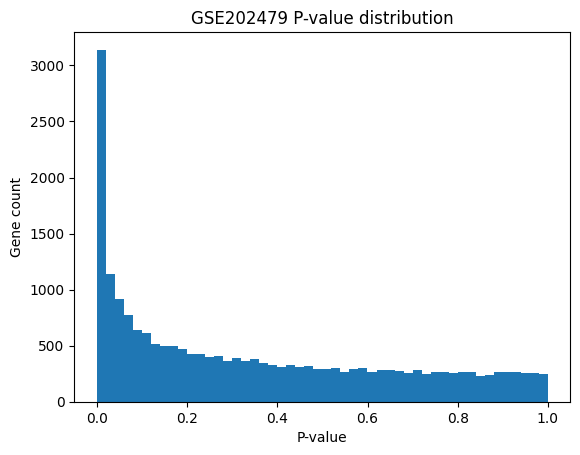

In [ ]:
import matplotlib.pyplot as plt
plt.hist(deg_202479['P.Value'], bins=50)
plt.xlabel('P-value')
plt.ylabel('Gene count')
plt.title('GSE202479 P-value distribution')
plt.show()

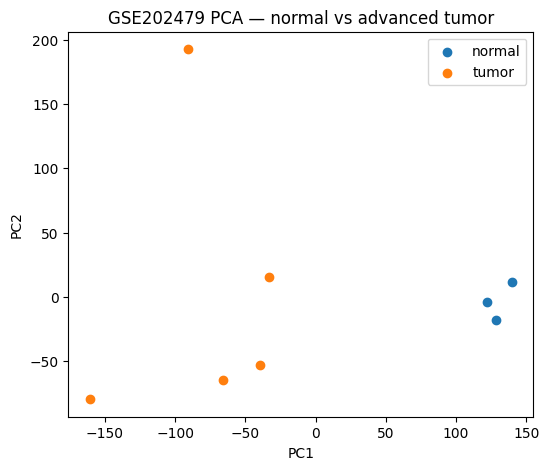

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

log_expr = np.log2(df_202479_subset[normal_count_cols + tumor_count_cols].values + 1)
pca = PCA(n_components=2)
coords = pca.fit_transform(log_expr.T)

labels = ['normal']*3 + ['tumor']*5
plt.figure(figsize=(6,5))
for label in set(labels):
    idx = [i for i, l in enumerate(labels) if l == label]
    plt.scatter(coords[idx,0], coords[idx,1], label=label)
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend()
plt.title('GSE202479 PCA — normal vs advanced tumor')
plt.show()